# DATE2 实验6：跨工作负载与系统配置鲁棒性

在26组配置上覆盖模型类别、专家数、Token数、Top-k、路由不平衡与随机种子、
以及Expert Parallel配置。论文只报告最终`MemDomain`；Raw仅用于解释失败原因。

必须区分两种口径：
1. 相对原始`Static-NoPF`的端到端收益；
2. 相对四个传统候选中最强者的MemDomain额外收益。


In [1]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scalesim.memory.memdomain_experiment import workload_digest
ROOT=Path.cwd().resolve().parent if Path.cwd().name=='fig' else Path.cwd().resolve()
OUT=ROOT/'outputs/DATE2';FIG=ROOT/'fig/DATE2';FIG.mkdir(parents=True,exist_ok=True)
PUBLIC=['Static-NoPF','Static-NaivePF','Dynamic-NoPF','Dynamic-NaivePF','MemDomain']
FINAL_INTERNAL='MemDomain-'+'Safe'
def public_rows(frame):
    q=frame[frame.baseline.isin(['Static-NoPF','Static-NaivePF','Dynamic-NoPF',
                                 'Dynamic-NaivePF',FINAL_INTERNAL])].copy()
    q['baseline']=q.baseline.replace({FINAL_INTERNAL:'MemDomain'})
    assert set(q.baseline)==set(PUBLIC)
    return q
def current_matrix(suite,stem):
    config=ROOT/'configs/MoE/DATE2'/suite/f'{stem}.json'
    output=OUT/suite/f'{stem}.csv'
    assert config.exists(),config
    assert output.exists(),f'Missing output: {output}'
    frame=pd.read_csv(output)
    expected=workload_digest(json.loads(config.read_text(encoding='utf-8')))
    assert set(frame.workload_hash)=={expected},f'Stale output: {output}'
    return frame

rows=[]
for config in sorted((ROOT/'configs/MoE/DATE2/robustness').glob('*.json')):
    q=current_matrix('robustness',config.stem).copy();q['variant']=config.stem;rows.append(q)
d=pd.concat(rows,ignore_index=True)
def classify(v):
    if v.startswith('class_'): return 'Model class'
    if v.startswith('experts_'): return 'Expert count'
    if v.startswith('tokens_'): return 'Token count'
    if v.startswith('topk_'): return 'Top-k'
    if v.startswith('ep_'): return 'Expert parallel'
    if '_seed' in v: return 'Routing seeds'
    if v.startswith('routing_'): return 'Routing severity'
    raise ValueError(v)
d['group']=d.variant.map(classify)
d['baseline']=d.baseline.replace({FINAL_INTERNAL:'MemDomain'})
assert d.variant.nunique()==26
assert d.groupby('variant').size().eq(7).all()
p=d.pivot(index='variant',columns='baseline',values='total_cycles')
conventional=['Static-NoPF','Static-NaivePF','Dynamic-NoPF','Dynamic-NaivePF']
best=p[conventional].min(axis=1)
summary=pd.DataFrame(index=p.index)
summary['group']=summary.index.map(classify)
summary['speedup_vs_static']=p['Static-NoPF']/p.MemDomain
summary['gain_vs_best_pct']=(best/p.MemDomain-1)*100
summary['raw_gain_vs_best_pct']=(best/p['MemDomain-Raw']-1)*100
summary['source']=d[d.baseline.eq('MemDomain')].set_index('variant').candidate_source
assert (summary.gain_vs_best_pct>=-1e-12).all()


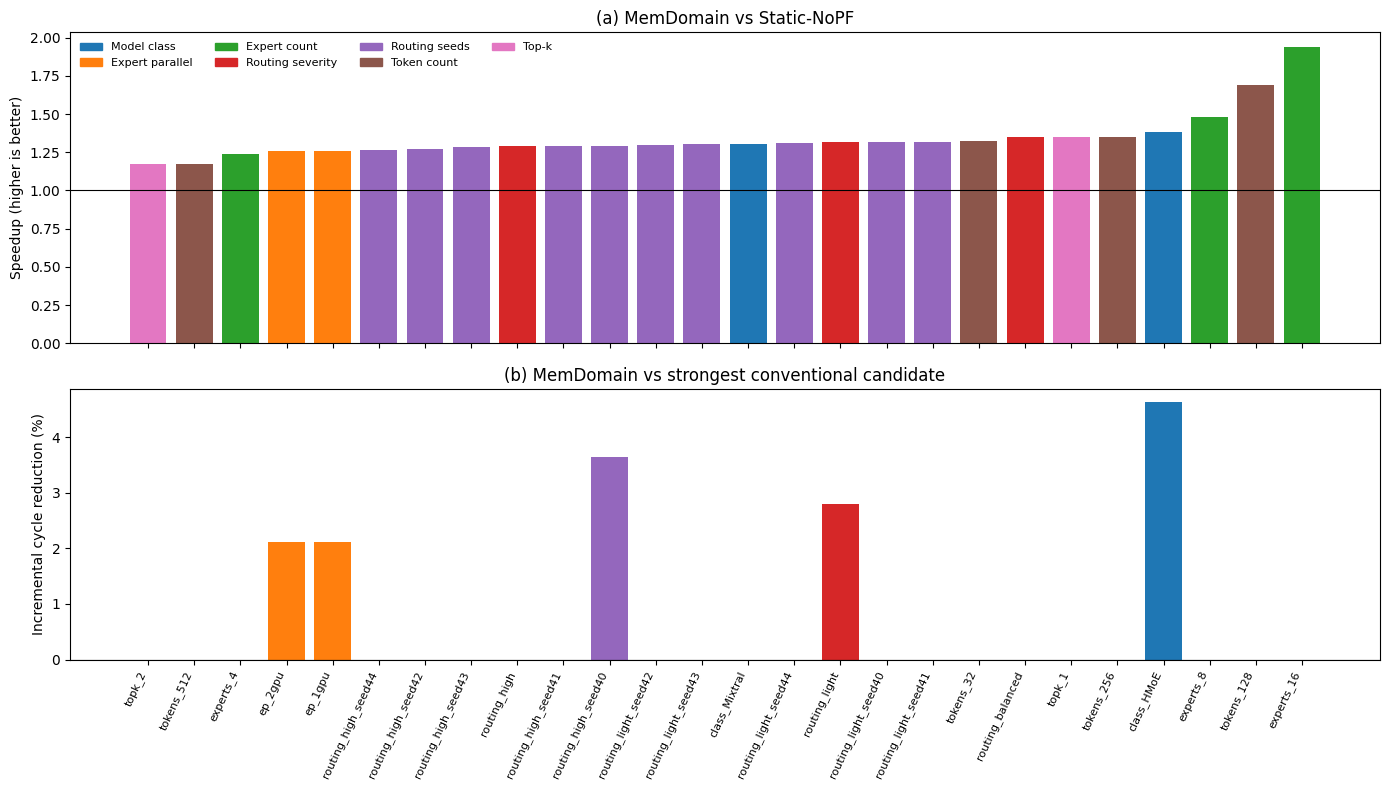

Positive speedup vs Static-NoPF: 26/26
Strict incremental wins: 5/26


In [2]:
colors={name:plt.cm.tab10(i) for i,name in enumerate(summary.group.unique())}
q=summary.sort_values('speedup_vs_static')
fig,axes=plt.subplots(2,1,figsize=(14,8),sharex=True,
                      gridspec_kw={'height_ratios':[1.15,1]})
x=np.arange(len(q));bar_colors=[colors[g] for g in q.group]
bars=axes[0].bar(x,q.speedup_vs_static,color=bar_colors)
axes[0].axhline(1,color='black',lw=.8)
axes[0].set_ylabel('Speedup (higher is better)')
axes[0].set_title('(a) MemDomain vs Static-NoPF')
bars=axes[1].bar(x,q.gain_vs_best_pct,color=bar_colors)
axes[1].axhline(0,color='black',lw=.8)
axes[1].set_ylabel('Incremental cycle reduction (%)')
axes[1].set_title('(b) MemDomain vs strongest conventional candidate')
axes[1].set_xticks(x,q.index,rotation=65,ha='right',fontsize=8)
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color=color,label=name) for name,color in colors.items()],
               ncol=4,frameon=False,fontsize=8)
plt.tight_layout();plt.savefig(FIG/'exp6_public_robustness.pdf',bbox_inches='tight');plt.show()
print(f'Positive speedup vs Static-NoPF: {(summary.speedup_vs_static>1).sum()}/26')
print(f'Strict incremental wins: {(summary.gain_vs_best_pct>1e-12).sum()}/26')


,configurations,min_speedup,mean_speedup,max_speedup,strict_joint_wins,mean_incremental_gain_pct,max_incremental_gain_pct
group,,,,,,,
Expert count,3,1.238,1.551,1.938,0,0.000,0.000
Expert parallel,2,1.258,1.259,1.259,2,2.110,2.114
Model class,2,1.303,1.341,1.380,1,2.314,4.629
Routing seeds,10,1.262,1.294,1.315,1,0.364,3.637
Routing severity,3,1.288,1.317,1.348,1,0.932,2.797
Token count,4,1.174,1.384,1.692,0,0.000,0.000
Top-k,2,1.174,1.261,1.348,0,0.000,0.000


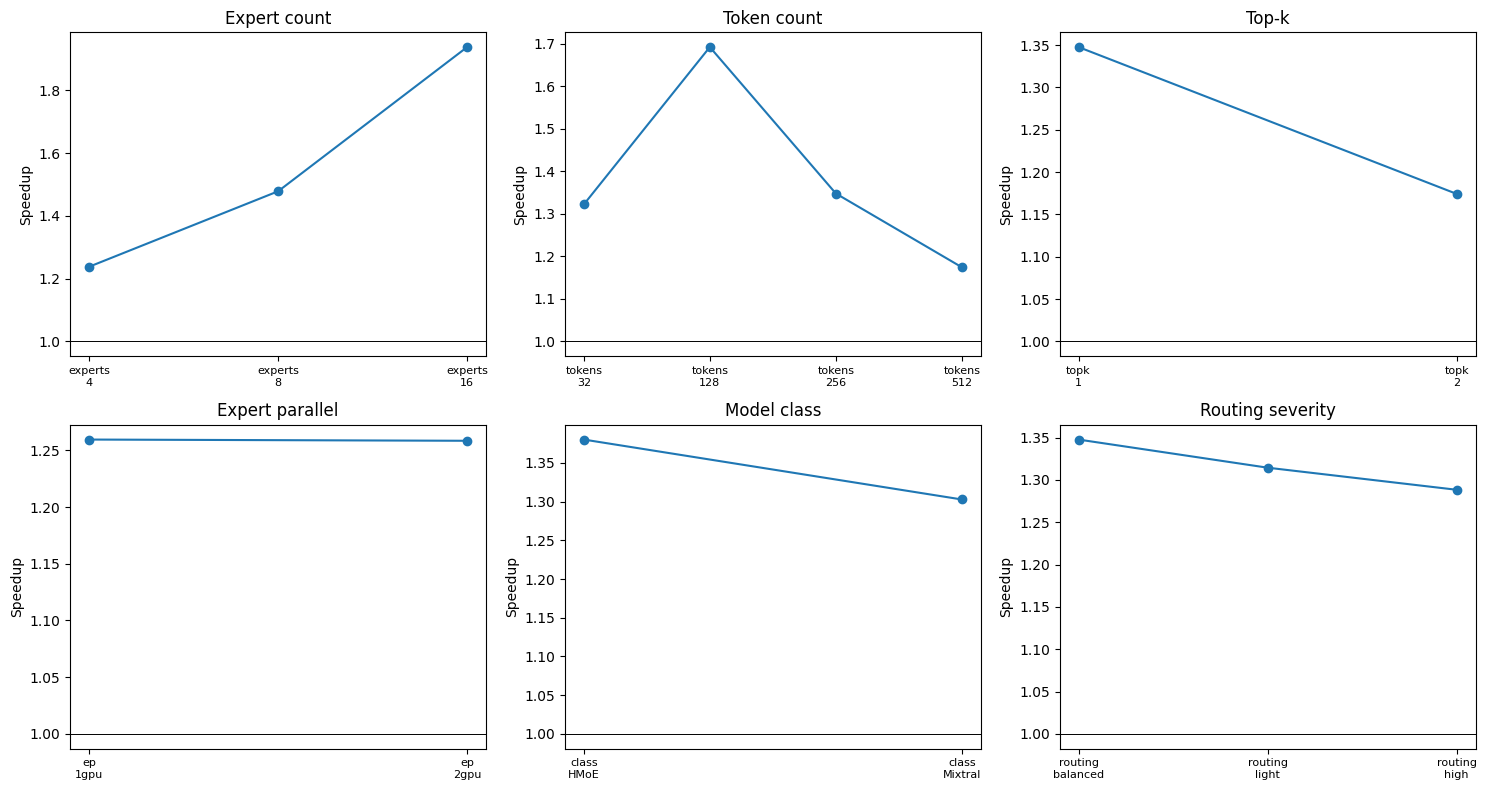

In [3]:
group_summary=summary.groupby('group').agg(
 configurations=('speedup_vs_static','size'),
 min_speedup=('speedup_vs_static','min'),
 mean_speedup=('speedup_vs_static','mean'),
 max_speedup=('speedup_vs_static','max'),
 strict_joint_wins=('gain_vs_best_pct',lambda x:int((x>1e-12).sum())),
 mean_incremental_gain_pct=('gain_vs_best_pct','mean'),
 max_incremental_gain_pct=('gain_vs_best_pct','max'))
display(group_summary.round(3))

ordered={
 'Expert count':['experts_4','experts_8','experts_16'],
 'Token count':['tokens_32','tokens_128','tokens_256','tokens_512'],
 'Top-k':['topk_1','topk_2'],
 'Expert parallel':['ep_1gpu','ep_2gpu'],
 'Model class':['class_HMoE','class_Mixtral'],
 'Routing severity':['routing_balanced','routing_light','routing_high']}
fig,axes=plt.subplots(2,3,figsize=(15,8));axes=axes.ravel()
for ax,(title,names) in zip(axes,ordered.items()):
    z=summary.loc[names]
    ax.plot(range(len(z)),z.speedup_vs_static,marker='o',label='vs Static-NoPF')
    ax.set_xticks(range(len(z)),[x.replace('_','\n') for x in names],fontsize=8)
    ax.axhline(1,color='black',lw=.7);ax.set_title(title);ax.set_ylabel('Speedup')
plt.tight_layout();plt.savefig(FIG/'exp6_dimension_trends.pdf',bbox_inches='tight');plt.show()


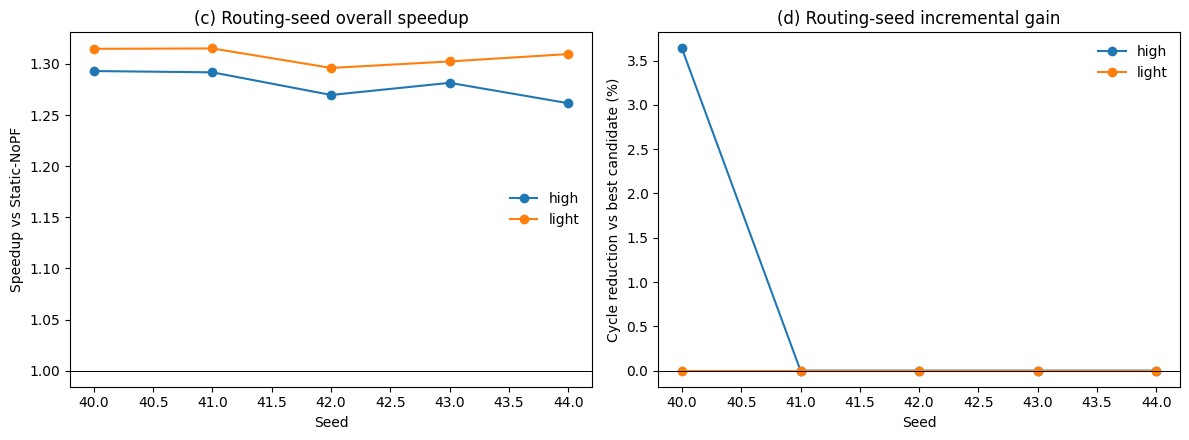

In [4]:
seed=summary[summary.group.eq('Routing seeds')].copy()
seed['severity']=seed.index.to_series().str.extract(r'routing_(light|high)')[0].values
seed['seed']=seed.index.to_series().str.extract(r'seed(\d+)')[0].astype(int).values
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
for severity,z in seed.groupby('severity'):
    z=z.sort_values('seed')
    axes[0].plot(z.seed,z.speedup_vs_static,marker='o',label=severity)
    axes[1].plot(z.seed,z.gain_vs_best_pct,marker='o',label=severity)
axes[0].axhline(1,color='black',lw=.7);axes[0].set_title('(c) Routing-seed overall speedup')
axes[0].set_ylabel('Speedup vs Static-NoPF');axes[0].set_xlabel('Seed')
axes[1].axhline(0,color='black',lw=.7);axes[1].set_title('(d) Routing-seed incremental gain')
axes[1].set_ylabel('Cycle reduction vs best candidate (%)');axes[1].set_xlabel('Seed')
for ax in axes:ax.legend(frameon=False)
plt.tight_layout();plt.savefig(FIG/'exp6_routing_seed_stability.pdf',bbox_inches='tight');plt.show()


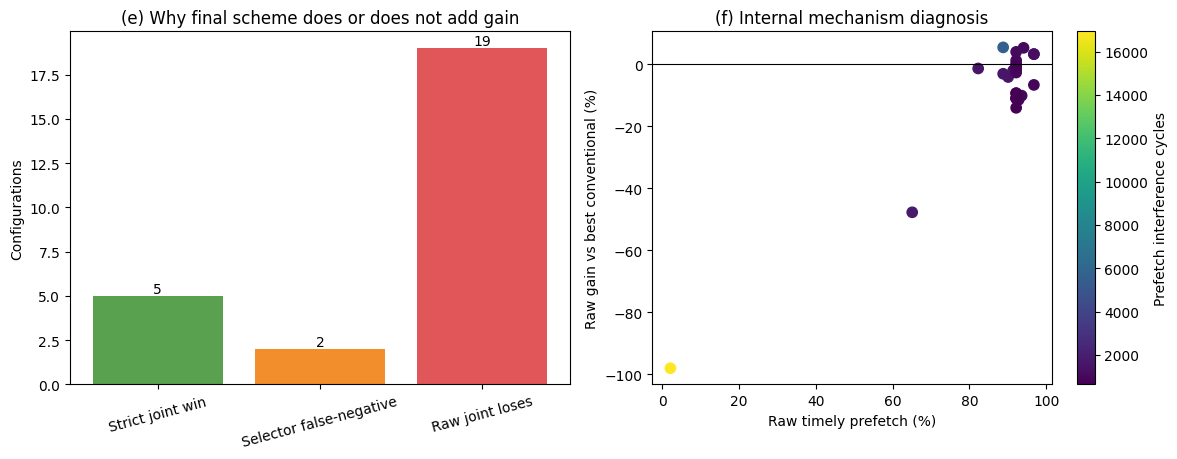

diagnosis
Raw joint loses            19
Selector false-negative     2
Strict joint win            5
Name: configurations, dtype: int64

,group,speedup_vs_static,gain_vs_best_pct,raw_gain_vs_best_pct,diagnosis
variant,,,,,
class_Mixtral,Model class,1.303,0.0,0.197,Selector false-negative
experts_16,Expert count,1.938,0.0,-11.459,Raw joint loses
experts_4,Expert count,1.238,0.0,-10.108,Raw joint loses
experts_8,Expert count,1.478,0.0,-6.638,Raw joint loses
routing_balanced,Routing severity,1.348,0.0,-10.965,Raw joint loses
routing_high,Routing severity,1.288,0.0,-4.084,Raw joint loses
routing_high_seed41,Routing seeds,1.292,0.0,-3.038,Raw joint loses
routing_high_seed42,Routing seeds,1.270,0.0,-47.773,Raw joint loses
routing_high_seed43,Routing seeds,1.282,0.0,-2.002,Raw joint loses


In [5]:
tol=1e-12
summary['diagnosis']=np.where(summary.gain_vs_best_pct>tol,'Strict joint win',
 np.where(summary.raw_gain_vs_best_pct>tol,'Selector false-negative','Raw joint loses'))
counts=summary.diagnosis.value_counts().reindex(
 ['Strict joint win','Selector false-negative','Raw joint loses'],fill_value=0)
raw_rows=d[d.baseline.eq('MemDomain-Raw')].set_index('variant')
fig,axes=plt.subplots(1,2,figsize=(12,4.7))
bars=axes[0].bar(counts.index,counts.values,color=['#59A14F','#F28E2B','#E15759'])
axes[0].bar_label(bars);axes[0].set_ylabel('Configurations')
axes[0].set_title('(e) Why final scheme does or does not add gain')
axes[0].tick_params(axis='x',rotation=15)
scatter=axes[1].scatter(raw_rows.timely_prefetch_ratio*100,
 summary.loc[raw_rows.index,'raw_gain_vs_best_pct'],
 c=raw_rows.prefetch_interference_stall_cycles,cmap='viridis',s=55)
axes[1].axhline(0,color='black',lw=.8);axes[1].set_xlabel('Raw timely prefetch (%)')
axes[1].set_ylabel('Raw gain vs best conventional (%)')
axes[1].set_title('(f) Internal mechanism diagnosis')
plt.colorbar(scatter,ax=axes[1],label='Prefetch interference cycles')
plt.tight_layout();plt.savefig(FIG/'exp6_failure_diagnosis.pdf',bbox_inches='tight');plt.show()
display(summary.groupby('diagnosis').size().rename('configurations'))
display(summary[summary.diagnosis.ne('Strict joint win')][
 ['group','speedup_vs_static','gain_vs_best_pct','raw_gain_vs_best_pct','diagnosis']].round(3))


## 论文判读边界

- 26/26相对Static-NoPF为正，说明完整系统在广泛配置下安全且有效；
- 只有严格高于最强传统候选的配置才能归因于联合优化本身；
- 回退配置必须区分“联合候选本身更差”和“在线选择器误判”，二者对应不同改进方向；
- 若严格收益覆盖率较低，只能声称鲁棒不回退，不能声称联合优化在所有配置上都有额外收益。
